In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display full dataframe info
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
sns.set(style="whitegrid")

In [19]:
df = pd.read_csv("/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [20]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Column types and missing values
df.info()

# Summary statistics for numeric columns
df.describe()

Dataset shape: (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [21]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Customer ID    243007
Description      4382
dtype: int64

In [22]:
# Check total duplicate rows
duplicate_rows = df.duplicated()
print("Total duplicate rows:", duplicate_rows.sum())

Total duplicate rows: 34335


In [23]:
# Remove rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])

# Convert to integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Remove duplicates
df = df.drop_duplicates()

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [32]:
# Save cleaned dataset
df.to_csv("OnlineRetail_Cleaned.csv", index=False)

In [24]:
# Number of unique customers
print("Unique customers:", df['Customer ID'].nunique())

# Number of unique products
print("Unique products:", df['Description'].nunique())

# Total sales per row
df['TotalPrice'] = df['Quantity'] * df['Price']
df.head()

Unique customers: 5942
Unique products: 5299


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


/tmp/ipykernel_55/1093636040.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


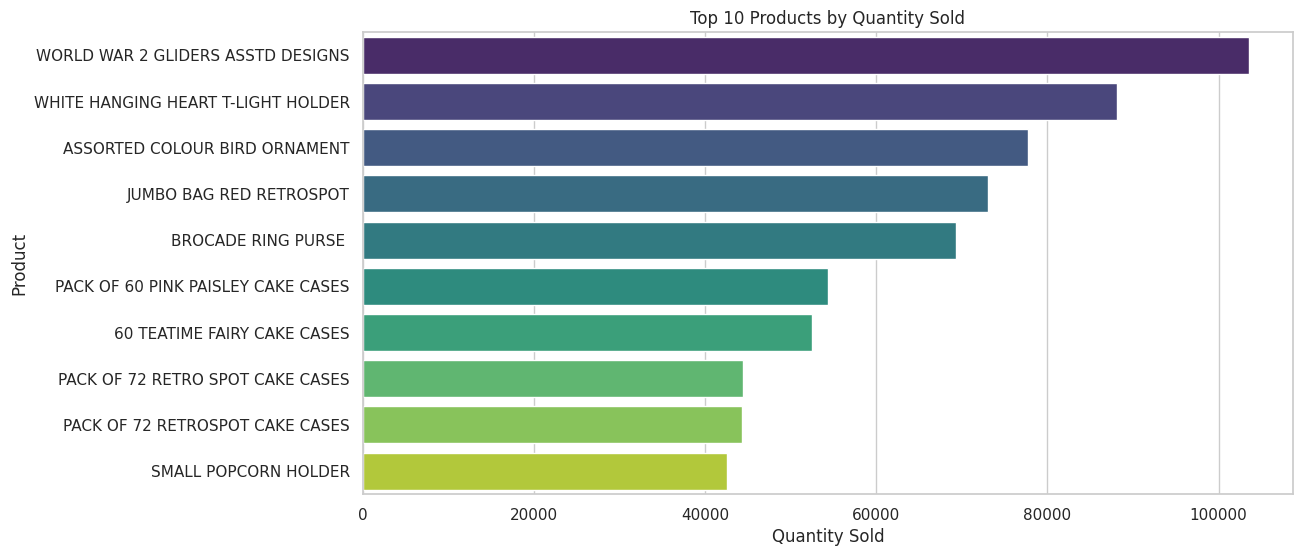

In [25]:
# Top 10 products by quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

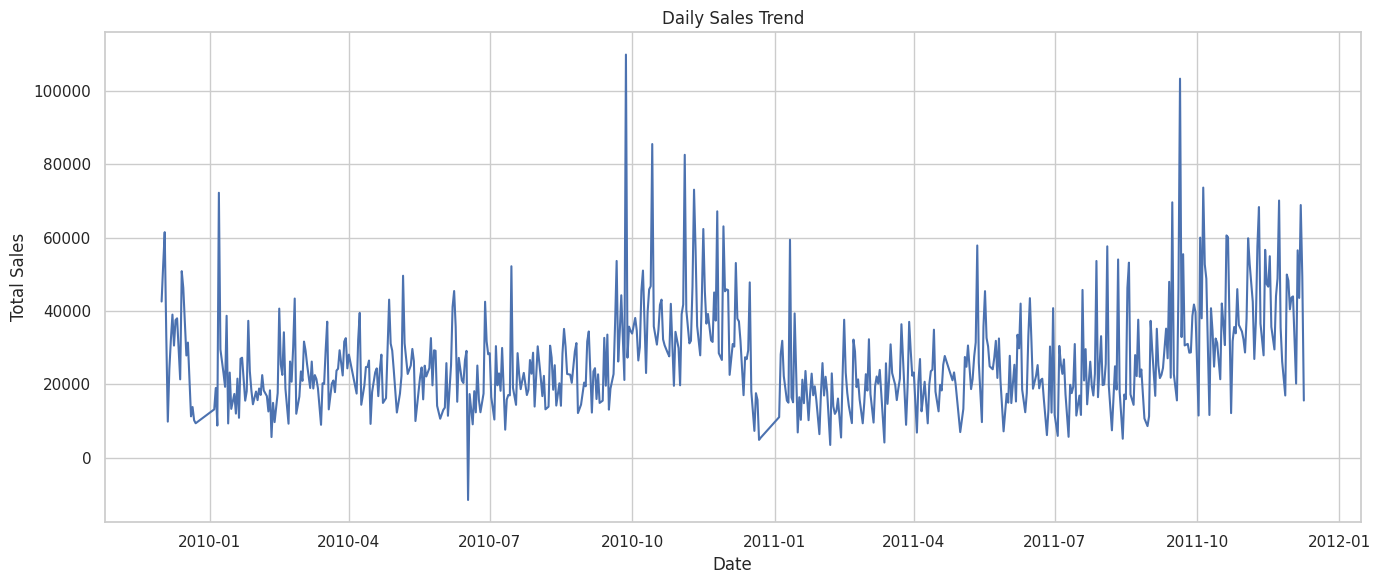

In [26]:
# Aggregate total sales per day
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

plt.figure(figsize=(14,6))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

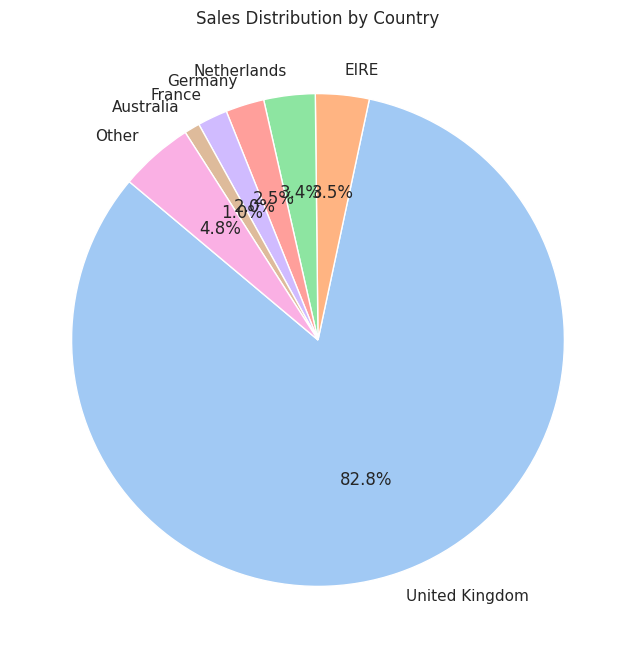

In [27]:
# Aggregate total sales by country
country_sales = df.groupby('Country')['TotalPrice'].sum()

# Pie chart (show top 6, others grouped as 'Other')
top_countries = country_sales.sort_values(ascending=False).head(6)
other = country_sales.sum() - top_countries.sum()
top_countries['Other'] = other

plt.figure(figsize=(8,8))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Sales Distribution by Country")
plt.show()

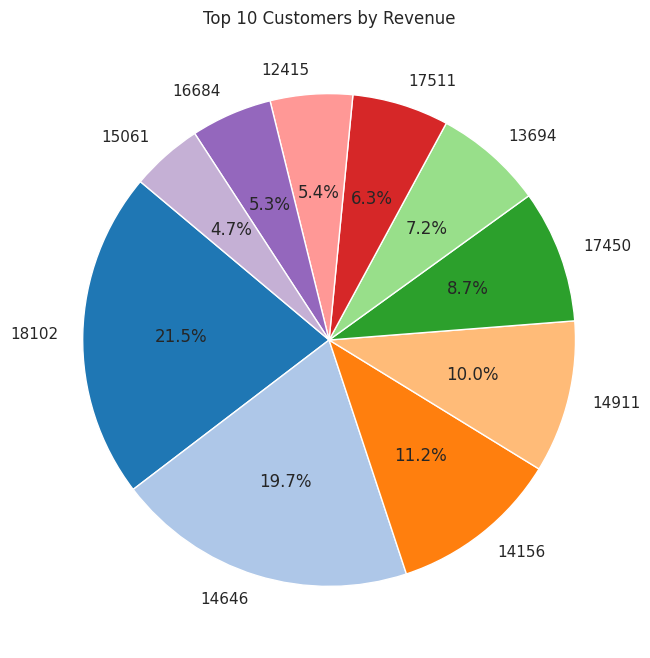

In [29]:
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))
plt.pie(top_customers, labels=top_customers.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("tab20"))
plt.title("Top 10 Customers by Revenue")
plt.show()

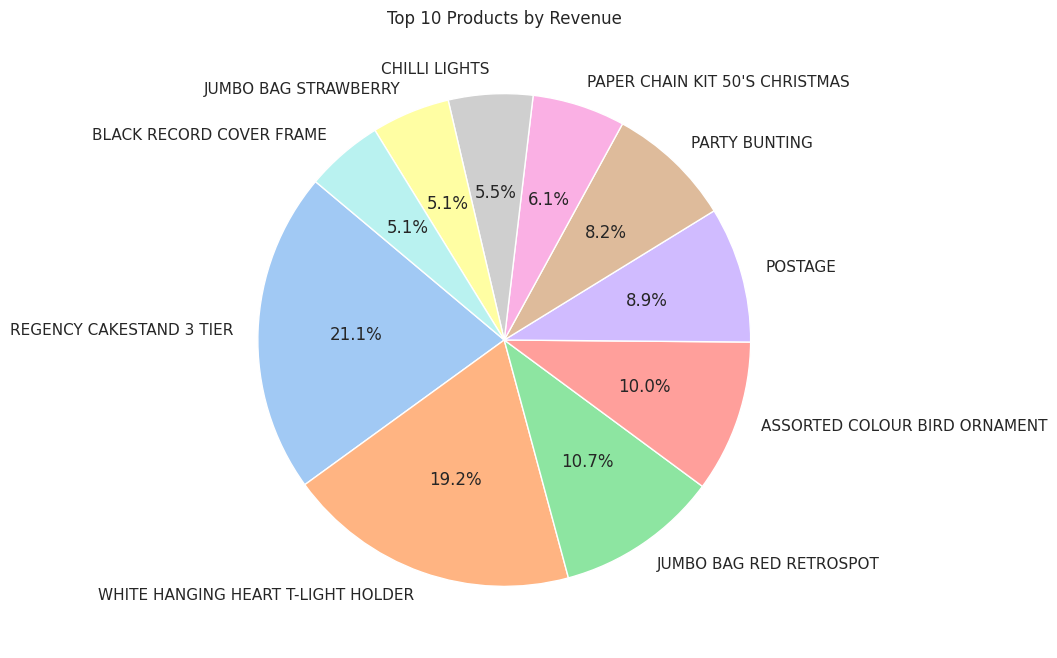

In [30]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Top 10 Products by Revenue")
plt.show()